In [1]:
import basedosdados as bd

In [2]:
project_id = "teste-ic-fairness"
query = """
SELECT
  d.id_inscricao,
  d.cor_raca,
  d.ensino,
  d.estado_civil,
  d.nota_matematica,
  d.sexo,
  d.sigla_uf_prova,
  d.tipo_escola,
  q.q006 AS renda_familiar,
  q.q025 AS tem_internet,
FROM
  `basedosdados.br_inep_enem.microdados` as d

INNER JOIN `basedosdados.br_inep_enem.questionario_socioeconomico_2023` as q
  ON q.id_inscricao = d.id_inscricao

WHERE d.ano = 2023
AND d.nota_matematica IS NOT NULL
AND d.ensino IS NOT NULL
AND d.sigla_uf_prova IS NOT NULL
LIMIT 5000;
"""

print("Testando conexão")
df = bd.read_sql(query, billing_project_id=project_id)

print(df)


Testando conexão
Downloading: 100%|██████████|
      id_inscricao cor_raca ensino estado_civil  nota_matematica sexo  \
0     210058297317        0      1            1            357.7    F   
1     210059006544        2      1            1            582.6    M   
2     210061691138        2      1            1            353.5    M   
3     210061366331        1      1            1            391.7    F   
4     210060924934        1      1            1            539.4    M   
...            ...      ...    ...          ...              ...  ...   
4995  210059281287        2      1            1            385.1    M   
4996  210059901357        2      1            1            355.3    M   
4997  210059914391        1      1            1            652.7    F   
4998  210060120013        3      1            1            448.8    F   
4999  210060260414        3      1            1            431.3    F   

     sigla_uf_prova tipo_escola renda_familiar tem_internet  
0             

In [3]:
df[df.notnull().all(1)]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210058297317,0,1,1,357.7,F,AM,2,B,B
1,210059006544,2,1,1,582.6,M,DF,2,C,B
2,210061691138,2,1,1,353.5,M,PA,2,B,B
3,210061366331,1,1,1,391.7,F,SC,2,B,B
4,210060924934,1,1,1,539.4,M,RR,2,O,B
...,...,...,...,...,...,...,...,...,...,...
4995,210059281287,2,1,1,385.1,M,SP,2,D,B
4996,210059901357,2,1,1,355.3,M,PE,2,B,B
4997,210059914391,1,1,1,652.7,F,BA,3,G,B
4998,210060120013,3,1,1,448.8,F,SP,2,C,B


In [4]:
df.head()

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210058297317,0,1,1,357.7,F,AM,2,B,B
1,210059006544,2,1,1,582.6,M,DF,2,C,B
2,210061691138,2,1,1,353.5,M,PA,2,B,B
3,210061366331,1,1,1,391.7,F,SC,2,B,B
4,210060924934,1,1,1,539.4,M,RR,2,O,B


In [5]:
df.describe()

,nota_matematica
count,5000.000000
mean,495.846560
std,111.488349
min,0.000000
25%,412.575000
50%,482.700000
75%,571.500000
max,931.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_inscricao     5000 non-null   object 
 1   cor_raca         5000 non-null   object 
 2   ensino           5000 non-null   object 
 3   estado_civil     5000 non-null   object 
 4   nota_matematica  5000 non-null   float64
 5   sexo             5000 non-null   object 
 6   sigla_uf_prova   5000 non-null   object 
 7   tipo_escola      5000 non-null   object 
 8   renda_familiar   5000 non-null   object 
 9   tem_internet     5000 non-null   object 
dtypes: float64(1), object(9)
memory usage: 390.8+ KB


In [7]:
df.nunique()

id_inscricao       5000
cor_raca              6
ensino                2
estado_civil          5
nota_matematica    2759
sexo                  2
sigla_uf_prova       27
tipo_escola           2
renda_familiar       17
tem_internet          2
dtype: int64

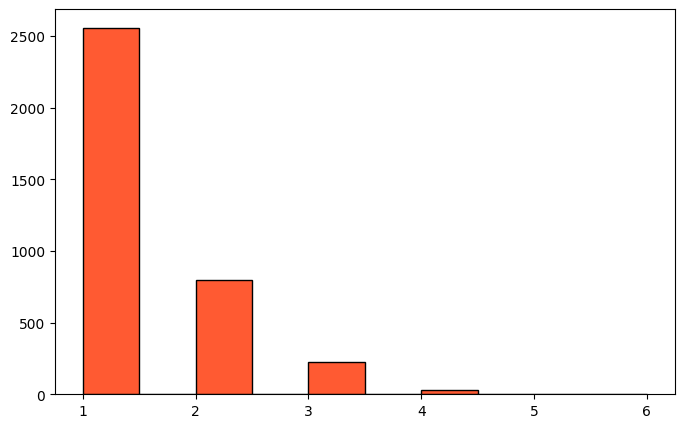

nota_matematica  sexo
0.0              M       1
338.1            F       1
                 M       1
338.7            F       1
339.1            M       1
                        ..
914.9            M       1
924.3            M       1
924.4            F       1
926.6            M       1
937.5            M       1
Name: count, Length: 3625, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# sns.scatterplot(
#     x='sexo',
#     y='nota_matematica',
#     alpha=0.7,
#     data=df,
# )

# dataX = df.groupby('nota_matematica')['sexo'].value_counts()
# plt.figure(figsize=(8, 5))
# plt.hist(dataX, color='#ff5a32', edgecolor='black')

# plt.show()

# dataX

# df.hist(figsize=(20, 20), bins=25)

In [ ]:
mapa_raca = {
    "0": 'Não Declarado',
    "1": 'Branca',
    "2": 'Preta',
    "3": 'Parda',
    "4": 'Amarela',
    "5": 'Indígena'
}

mapa_escola = {
    "1": 'Não Respondido',
    "2": 'Pública',
    "3": 'Privada'
}

mapa_internet = {'A': 'Não', 'B': 'Sim'}

# Substituindo no DataFrame
df_visualizacao = df.copy()
df_visualizacao['cor_raca'] = df_visualizacao['cor_raca'].map(mapa_raca)
df_visualizacao['tipo_escola'] = df_visualizacao['tipo_escola'].map(mapa_escola)
df_visualizacao['tem_internet'] = df_visualizacao['tem_internet'].map(mapa_internet)

df_visualizacao.head(10)

# Esse dataFrame facilita a visualização de alguns dados, como raça, tipo da escola, que são atributos importantes.

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet
0,210058297317,Não Declarado,1,1,357.7,F,AM,Pública,B,Sim
1,210059006544,Preta,1,1,582.6,M,DF,Pública,C,Sim
2,210061691138,Preta,1,1,353.5,M,PA,Pública,B,Sim
3,210061366331,Branca,1,1,391.7,F,SC,Pública,B,Sim
4,210060924934,Branca,1,1,539.4,M,RR,Pública,O,Sim
5,210060230181,Parda,1,1,372.7,F,BA,Pública,B,Não
6,210059566730,Branca,1,1,409.3,F,SP,Pública,C,Sim
7,210058312930,Parda,1,1,419.6,M,AM,Pública,G,Sim
8,210060836099,Preta,1,1,558.4,M,DF,Privada,L,Sim
9,210060240738,Parda,1,1,417.9,F,AM,Pública,A,Sim


In [14]:
df[df['id_inscricao'].duplicated()]

,id_inscricao,cor_raca,ensino,estado_civil,nota_matematica,sexo,sigla_uf_prova,tipo_escola,renda_familiar,tem_internet


In [ ]:
df_visualizacao[df_visualizacao['tipo_escola'] == "Privada"].count()

# podemos ver que a minoria dos alunos é de escola particular (o que seria uma vantagem)

id_inscricao       437
cor_raca           437
ensino             437
estado_civil       437
nota_matematica    437
sexo               437
sigla_uf_prova     437
tipo_escola        437
renda_familiar     437
tem_internet       437
dtype: int64

In [ ]:
dataEscola = df_visualizacao.groupby('tipo_escola')['nota_matematica'].mean().sort_values(ascending=False)
dataEscola

# aqui vemos também que a escola pública tem uma nota máxima maior em matemática do que a escola privada
# contudo, a privada tem uma média de quase 100 pontos maior que a pública

tipo_escola
Privada    581.566133
Pública    487.637169
Name: nota_matematica, dtype: float64

In [ ]:
dataGender = df_visualizacao.groupby('sexo')['nota_matematica'].mean().sort_values(ascending=False)
dataGender

# vemos que a máxima feminina é maior que a máxima masculina
# porém a média masculina é maior que a feminina

sexo
M    515.394734
F    486.365667
Name: nota_matematica, dtype: float64

In [62]:
dataRenda = df_visualizacao.groupby('renda_familiar')['nota_matematica'].mean().sort_values(ascending=False)
dataRenda

# rendas maiores tendém a irem melhores. A renda Q (> 20 sslários minímos) tem o segundo maior máximo e a maior média
# enquanto a renda A (sem renda) tem a pior média e máxima

renda_familiar
Q    671.328571
P    652.628571
L    598.446429
J    594.621818
O    584.406250
M    572.750000
I    572.115000
N    569.938889
K    563.902778
H    558.011966
G    553.641091
F    532.782039
E    510.365891
D    507.641681
C    498.494186
B    469.939510
A    445.233492
Name: nota_matematica, dtype: float64

In [57]:
dataRace = df_visualizacao.groupby('cor_raca')['nota_matematica'].mean().sort_values(ascending=False)
dataRace

cor_raca
Branca           520.937130
Não Declarado    493.114815
Amarela          487.193617
Parda            481.887957
Preta            473.131609
Indígena         438.917949
Name: nota_matematica, dtype: float64